# 05 - Visualization
Spatial predictions, error maps, RMSE over time, training history.

**Inputs (from Notebooks 03 and 04):** `predictions.npy`, `y_test.npy`, `training_history.json`

**Outputs:** `obs_vs_pred.png`, `error_maps.png`, `rmse_over_time.png`, `training_history.png`

> **Note on latitude extent:** `bbox_model` lat range is 10-20 N, but plots use 7-20 N
> for geographic context (South China Sea / WPS coastline framing).

In [1]:
!pip install -q matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os
from google.colab import drive

drive.mount('/content/drive')

CONFIG = {
    # ------------------------------------------------------------------
    # Spatial
    # ------------------------------------------------------------------
    # Broad staging bbox (Notebook 01 raw cache)
    'bbox_regional': {
        'lat_min': 0,   'lat_max': 30,
        'lon_min': 110, 'lon_max': 140,
    },
    # WPS model bbox (Notebook 02 onward)
    'bbox_model': {
        'lat_min': 10,  'lat_max': 20,
        'lon_min': 114, 'lon_max': 120,
    },

    # ------------------------------------------------------------------
    # Temporal
    # ------------------------------------------------------------------
    'date_full':  {'start': '2014-01-01', 'end': '2024-12-31'},
    'date_model': {'start': '2019-01-01', 'end': '2024-12-31'},

    # ------------------------------------------------------------------
    # Paths
    # ------------------------------------------------------------------
    'data_dir': '/content/drive/MyDrive/fishing_project/',
    'files': {
        # Source CMEMS NetCDF files placed in data_dir by the user
        'physics_w_nc':  'cmems_mod_glo_phy_my_0.083deg_P1M-m_1779636039565.nc',
        'physics_ht_nc': 'cmems_mod_glo_phy_my_0.083deg_P1M-m_1779635380319.nc',
        'bgc_src_nc':    'cmems_mod_glo_bgc_my_0.25deg_P1M-m_1779635372583.nc',
        # 01 outputs -> 02 inputs
        'physics_nc':    'physics_raw_region.nc',
        'bgc_nc':        'bgc_raw_region.nc',
        'ais_parquet':   'ais_raw_region.parquet',
        'ais_csv_gz':    'ais_raw_region.csv.gz',
        # 02 outputs -> 03 inputs
        'ais_gridded_nc':  'ais_fishing_effort_gridded.nc',
        'preprocessed_nc': 'preprocessed_features.nc',
        # 03 outputs -> 04 / 05 / dashboard inputs
        'model_keras':     'convlstm_model.keras',
        'best_model':      'best_model.keras',
        'X_test_npy':      'X_test.npy',
        'y_test_npy':      'y_test.npy',
        'history_json':    'training_history.json',
        'summary_json':    'data_summary.json',
        # 04 outputs -> 05 / dashboard inputs
        'predictions_npy': 'predictions.npy',
        'eval_csv':        'evaluation_results.csv',
    },

    # ------------------------------------------------------------------
    # AIS
    # ------------------------------------------------------------------
    'ais_use_cols': ['date', 'cell_ll_lat', 'cell_ll_lon', 'fishing_hours'],

    # ------------------------------------------------------------------
    # Depth selection for CMEMS variables
    # ------------------------------------------------------------------
    'physics_surface_depth': 0.49,   # metres, nearest-neighbour selection
    'bgc_depth_range': (0.51, 5.14), # metres, averaged over this range

    # ------------------------------------------------------------------
    # Preprocessing
    # ------------------------------------------------------------------
    'norm_method':   'minmax',
    'resample_freq': '1ME',

    # ------------------------------------------------------------------
    # Model / Training
    # ------------------------------------------------------------------
    'seq_len':    3,     # months of input context fed to ConvLSTM
    'pred_len':   1,     # months ahead to predict
    'n_channels': 7,     # sst, ssh, vo, uo, chl, nppv, fishing_effort
    'train_frac': 0.70,
    'val_frac':   0.15,
    # test_frac = 1 - 0.70 - 0.15 = 0.15
    'epochs':     50,
    'batch_size': 8,
    'patience':   10,

    # ------------------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------------------
    'f1_threshold': 0.1,   # binarization threshold for F1 score in 04_evaluation,   # binarization threshold for F1 score in 04_evaluation
}

DATA_DIR   = CONFIG['data_dir']
f          = CONFIG['files']


Mounted at /content/drive


In [3]:
# CELL: load predictions and test labels from Notebooks 03 and 04
y_test = np.load(DATA_DIR + f['y_test_npy'])
preds  = np.load(DATA_DIR + f['predictions_npy'])

print(f'y_test shape : {y_test.shape}')   # Expected: (N, 41, 25, 1)
print(f'preds shape  : {preds.shape}')    # Expected: (N, 41, 25, 1)

# -----------------------------------------------------------------------
# Spatial extents
# -----------------------------------------------------------------------
bm = CONFIG['bbox_model']
LON_MIN, LON_MAX = bm['lon_min'], bm['lon_max']
# bbox_model lat is 10-20 deg N; we pad the viz extent downward to 7 deg N
# for geographic context (matching the original 05_visualization layout).
LAT_MIN_VIZ, LAT_MAX_VIZ = 7, bm['lat_max']
LAT_MIN_DATA, LAT_MAX_DATA = bm['lat_min'], bm['lat_max']

print(f'Visualization extent : lat {LAT_MIN_VIZ}-{LAT_MAX_VIZ} N,  '
      f'lon {LON_MIN}-{LON_MAX} E')


y_test shape : (11, 41, 25, 1)
preds shape  : (11, 41, 25, 1)
Visualization extent : lat 7-20 N,  lon 114-120 E


In [4]:
# CELL: define the custom fishing probability colormap
# Identical to the colormap used in Full_ConvLSTM.py dashboard.
cmap = LinearSegmentedColormap.from_list(
    'fishing',
    ['#000033', '#0000FF', '#FF00FF', '#FF0000'],
)


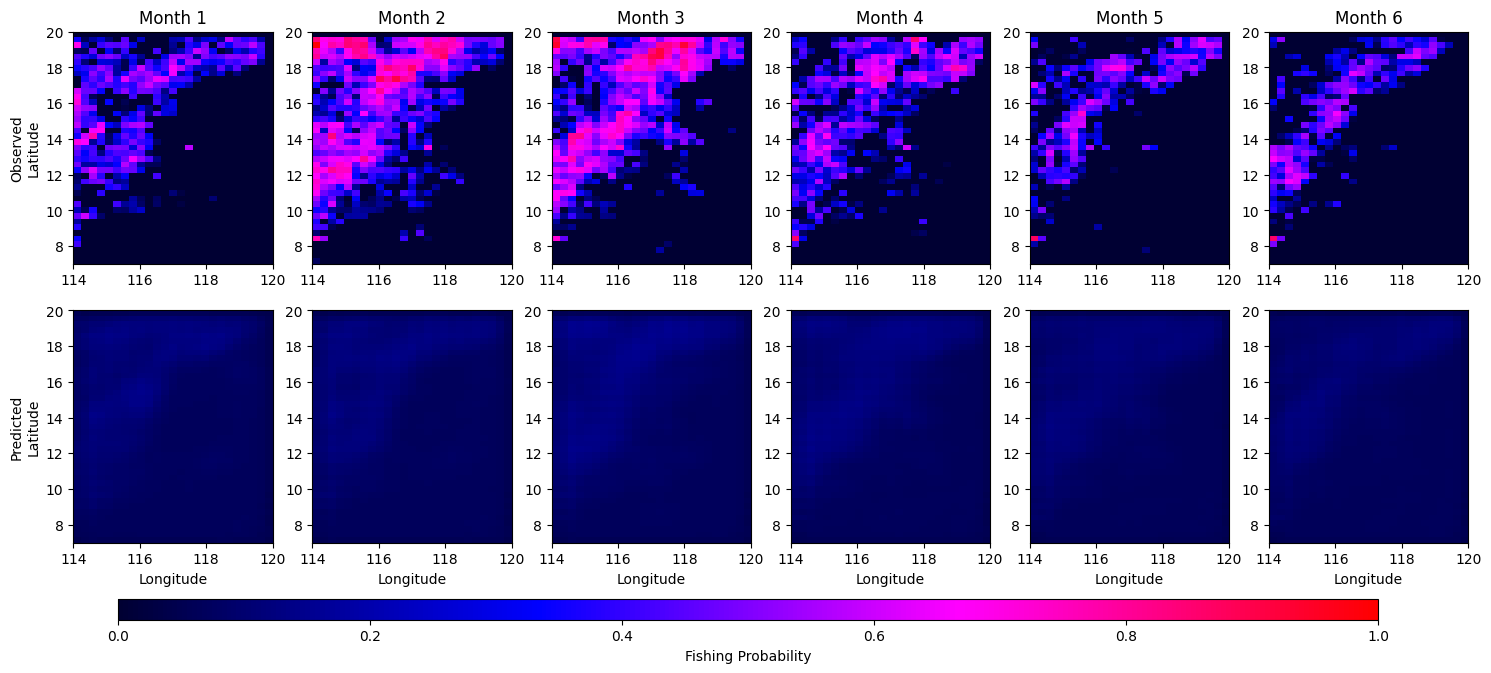

In [5]:
# CELL: Figure 1 -- observed vs predicted (up to 6 test samples)
n_samples = min(6, len(y_test))
fig, axes = plt.subplots(2, n_samples, figsize=(18, 7))

for i in range(n_samples):
    # -- Observed --
    axes[0, i].imshow(
        y_test[i, :, :, 0],
        extent=[LON_MIN, LON_MAX, LAT_MIN_VIZ, LAT_MAX_VIZ],
        cmap=cmap, vmin=0, vmax=1, aspect='auto', origin='lower',
    )
    axes[0, i].set_title(f'Month {i+1}')
    if i == 0:
        axes[0, i].set_ylabel('Observed\nLatitude')

    # -- Predicted --
    im = axes[1, i].imshow(
        preds[i, :, :, 0],
        extent=[LON_MIN, LON_MAX, LAT_MIN_VIZ, LAT_MAX_VIZ],
        cmap=cmap, vmin=0, vmax=1, aspect='auto', origin='lower',
    )
    if i == 0:
        axes[1, i].set_ylabel('Predicted\nLatitude')
    axes[1, i].set_xlabel('Longitude')

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Fishing Probability')
plt.savefig(DATA_DIR + 'obs_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()


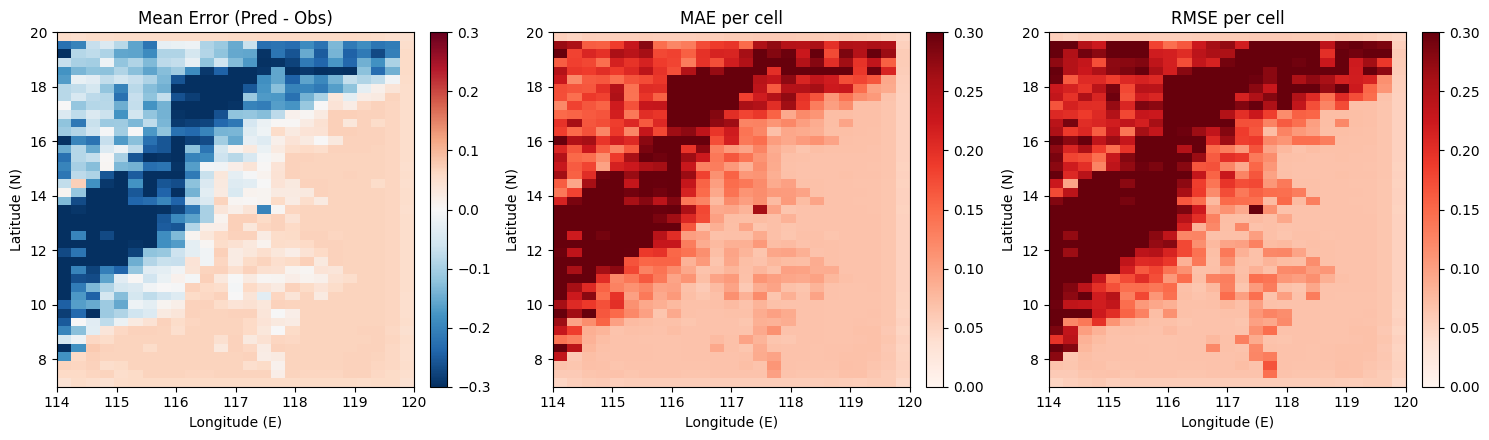

In [6]:
# CELL: Figure 2 -- spatial error maps averaged across all test samples
# err = preds - y_test  (positive = model over-predicts)
err_arr  = preds - y_test                                # (N, 41, 25, 1)
mean_err = err_arr.mean(axis=0)[:, :, 0]
mae_map  = np.abs(err_arr).mean(axis=0)[:, :, 0]
rmse_map = np.sqrt((err_arr**2).mean(axis=0))[:, :, 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [
    (mean_err, 'RdBu_r', -0.3,  0.3, 'Mean Error (Pred - Obs)'),
    (mae_map,  'Reds',    0.0,  0.3, 'MAE per cell'),
    (rmse_map, 'Reds',    0.0,  0.3, 'RMSE per cell'),
]
for ax, (arr, cmap_name, vmin, vmax, title) in zip(axes, panels):
    im = ax.imshow(
        arr,
        extent=[LON_MIN, LON_MAX, LAT_MIN_VIZ, LAT_MAX_VIZ],
        cmap=cmap_name, vmin=vmin, vmax=vmax,
        aspect='auto', origin='lower',
    )
    ax.set_title(title)
    ax.set_xlabel('Longitude (E)')
    ax.set_ylabel('Latitude (N)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(DATA_DIR + 'error_maps.png', dpi=300, bbox_inches='tight')
plt.show()


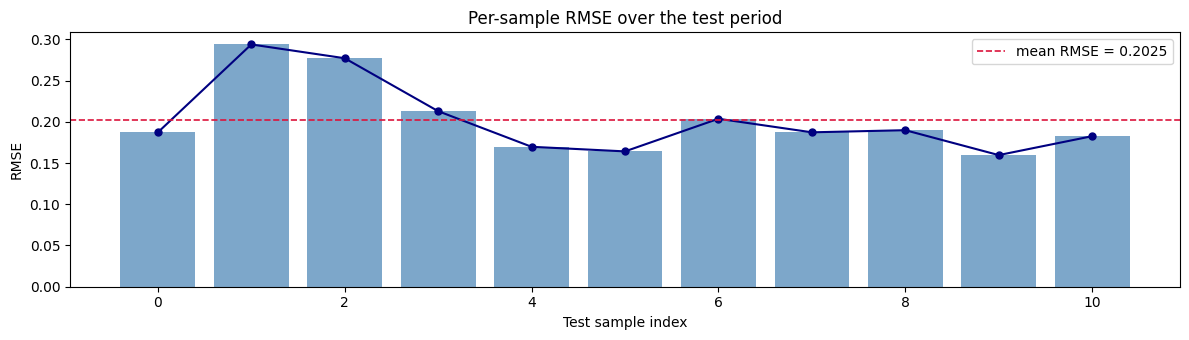

In [7]:
# CELL: Figure 3 -- per-sample RMSE over the test period
from sklearn.metrics import mean_squared_error

rmse_list = [
    float(np.sqrt(mean_squared_error(
        np.nan_to_num(y_test[i].flatten(), nan=0.0),
        np.nan_to_num(preds[i].flatten(),  nan=0.0),
    )))
    for i in range(len(y_test))
]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(len(rmse_list)), rmse_list, alpha=0.7, color='steelblue')
ax.plot(range(len(rmse_list)), rmse_list,
        color='navy', linewidth=1.5, marker='o', markersize=5)
ax.axhline(float(np.mean(rmse_list)), color='crimson', linewidth=1.2,
           linestyle='--', label=f'mean RMSE = {np.mean(rmse_list):.4f}')
ax.set_xlabel('Test sample index')
ax.set_ylabel('RMSE')
ax.set_title('Per-sample RMSE over the test period')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR + 'rmse_over_time.png', dpi=300, bbox_inches='tight')
plt.show()


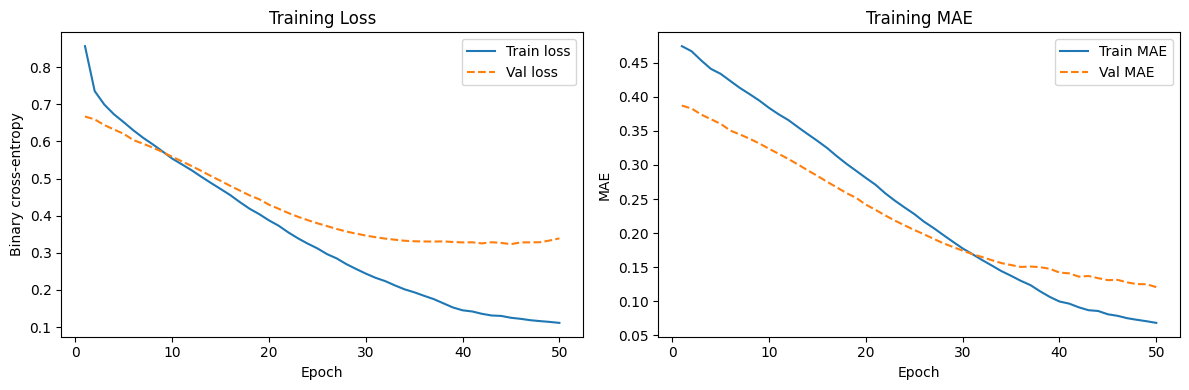

Notebook 05 complete.


In [8]:
# CELL: Figure 4 -- training history curves
import json as _json

history_path = DATA_DIR + f['history_json']
if not os.path.exists(history_path):
    print(f'training_history.json not found at {history_path}.')
    print('Run 03_model_training.ipynb first.')
else:
    with open(history_path) as fh:
        history_dict = _json.load(fh)

    loss_tr = history_dict.get('loss', [])
    loss_vl = history_dict.get('val_loss', [])
    mae_tr  = history_dict.get('mae', history_dict.get('mean_absolute_error', []))
    mae_vl  = history_dict.get('val_mae', history_dict.get('val_mean_absolute_error', []))
    epochs  = list(range(1, len(loss_tr) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, loss_tr, label='Train loss')
    ax1.plot(epochs[:len(loss_vl)], loss_vl, linestyle='--', label='Val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Binary cross-entropy')
    ax1.set_title('Training Loss'); ax1.legend()

    ax2.plot(epochs, mae_tr, label='Train MAE')
    ax2.plot(epochs[:len(mae_vl)], mae_vl, linestyle='--', label='Val MAE')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE')
    ax2.set_title('Training MAE'); ax2.legend()

    plt.tight_layout()
    plt.savefig(DATA_DIR + 'training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Notebook 05 complete.')
